In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt

# Data preprocessing

In [39]:
data = pd.read_csv('data/weatherAUS.csv') # 145460 rows, 23 columns
# data.head()

In [41]:
# delete rows with missing values in any column
data_cleaned = data.dropna()
# len(data_cleaned) # 56420 rows left

In [42]:
# drop irrelevant columns
data_cleaned = data_cleaned.drop(columns=['Date', 'Location'])
# data_cleaned.head()

In [44]:
# print unique values for WindGustDir, WindDir9am, and WindDir3pm
# print(data_cleaned['WindGustDir'].unique())
# print(data_cleaned['WindDir9am'].unique())
# print(data_cleaned['WindDir3pm'].unique())

In [45]:
# create dictionary to map wind directions to degrees
wind_direction_mapping = {
    'N': 0,
    'NNE': 22.5,
    'NE': 45,
    'ENE': 67.5,
    'E': 90,
    'ESE': 112.5,
    'SE': 135,
    'SSE': 157.5,
    'S': 180,
    'SSW': 202.5,
    'SW': 225,
    'WSW': 247.5,
    'W': 270,
    'WNW': 292.5,
    'NW': 315,
    'NNW': 337.5
}

# map wind directions to degrees
data_cleaned['WindGustDir_deg'] = data_cleaned['WindGustDir'].map(wind_direction_mapping)
data_cleaned['WindDir9am_deg'] = data_cleaned['WindDir9am'].map(wind_direction_mapping)
data_cleaned['WindDir3pm_deg'] = data_cleaned['WindDir3pm'].map(wind_direction_mapping)
# drop original wind direction columns
data_cleaned = data_cleaned.drop(columns=['WindGustDir', 'WindDir9am', 'WindDir3pm'])
# cyclical encoding for wind direction features
data_cleaned['WindGustDir_sin'] = np.sin(np.radians(data_cleaned['WindGustDir_deg']))
data_cleaned['WindGustDir_cos'] = np.cos(np.radians(data_cleaned['WindGustDir_deg']))
data_cleaned['WindDir9am_sin'] = np.sin(np.radians(data_cleaned['WindDir9am_deg']))
data_cleaned['WindDir9am_cos'] = np.cos(np.radians(data_cleaned['WindDir9am_deg']))
data_cleaned['WindDir3pm_sin'] = np.sin(np.radians(data_cleaned['WindDir3pm_deg']))
data_cleaned['WindDir3pm_cos'] = np.cos(np.radians(data_cleaned['WindDir3pm_deg']))
# drop degree columns
data_cleaned = data_cleaned.drop(columns=['WindGustDir_deg', 'WindDir9am_deg', 'WindDir3pm_deg'])
# data_cleaned.head()

In [ ]:
# one-hot encoding for categorical features (except target variable 'RainTomorrow')
categorical_columns = data_cleaned.select_dtypes(include=['object']).columns.tolist()
categorical_columns.remove('RainTomorrow')
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(data_cleaned[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns), index=data_cleaned.index)
df_encoded = pd.concat([data_cleaned, one_hot_df], axis=1)
df_encoded = df_encoded.drop(categorical_columns, axis=1)
# df_encoded.head()

In [47]:
# split into training and test sets
df_encoded_copy = df_encoded.copy()
X = df_encoded_copy.drop('RainTomorrow', axis=1)
y = df_encoded_copy['RainTomorrow'].map({'No': 0, 'Yes': 1}) # convert target variable to binary
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=188834)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((45136, 24), (11284, 24), (45136,), (11284,))

In [48]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [49]:
# create a second dataset without the cyclical features for comparison
df_encoded_copy2 = df_encoded.copy()
df_no_cyclical = df_encoded_copy2.drop(columns=['WindGustDir_sin', 'WindGustDir_cos', 'WindDir9am_sin', 'WindDir9am_cos', 'WindDir3pm_sin', 'WindDir3pm_cos'])
X_no_cyclical = df_no_cyclical.drop('RainTomorrow', axis=1)
y_no_cyclical = df_no_cyclical['RainTomorrow'].map({'No': 0, 'Yes': 1})
X_train_no_cyclical, X_test_no_cyclical, y_train_no_cyclical, y_test_no_cyclical = train_test_split(X_no_cyclical, y_no_cyclical, test_size=0.2, random_state=188834)
X_train_no_cyclical = scaler.fit_transform(X_train_no_cyclical)
X_test_no_cyclical = scaler.transform(X_test_no_cyclical)

# Model training and evaluation

In [50]:
classifier = RandomForestClassifier(n_estimators=100, random_state=188834)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

In [51]:
classifier.fit(X_train_no_cyclical, y_train_no_cyclical)
y_pred_no_cyclical = classifier.predict(X_test_no_cyclical)

In [52]:
def evaluate_model(y_test, y_pred):
    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy: {accuracy * 100:.2f}%')

    # F1 Score
    f1 = f1_score(y_test, y_pred)
    print(f'F1 Score: {f1:.4f}')

    # Confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    plt.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
    plt.title('Confusion Matrix Heatmap')
    plt.colorbar()

    class_labels = [str(label) for label in np.unique(y_test)]
    tick_marks = np.arange(len(class_labels))
    plt.xticks(tick_marks, class_labels)
    plt.yticks(tick_marks, class_labels)

    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            plt.text(j, i, conf_matrix[i, j],
                     ha='center', va='center',
                     color='black')

    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.tight_layout()
    plt.show()

Accuracy: 86.04%
F1 Score: 0.6321


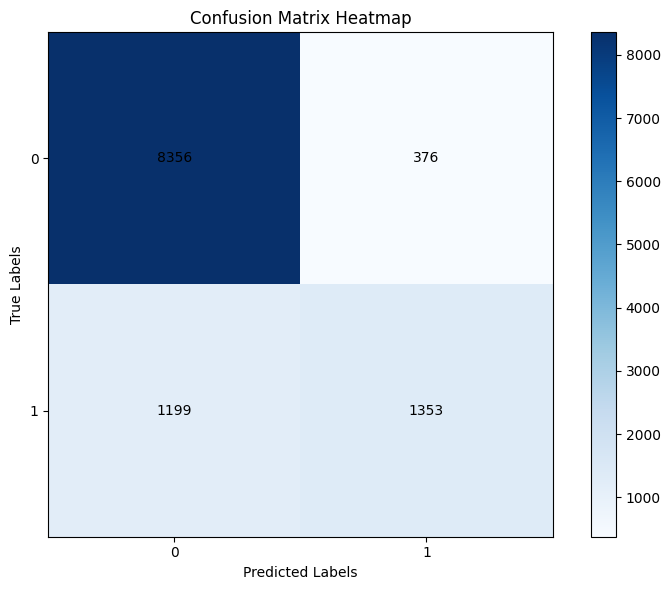

In [53]:
evaluate_model(y_test, y_pred)

Accuracy: 86.40%
F1 Score: 0.6414


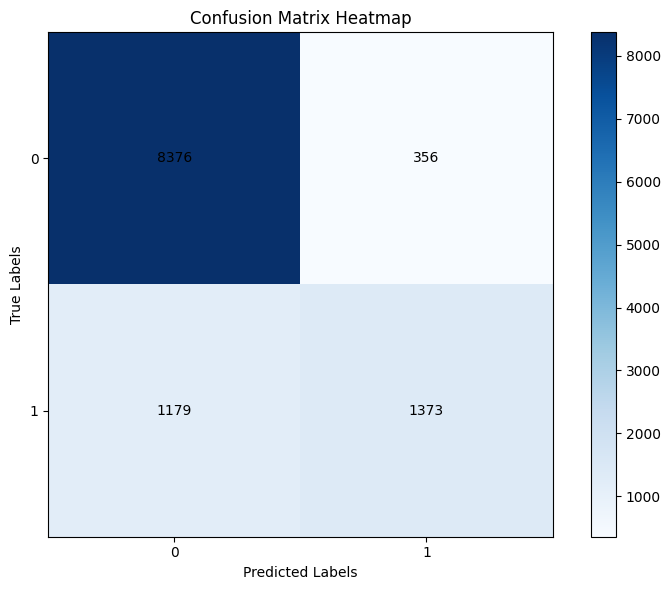

In [54]:
evaluate_model(y_test_no_cyclical, y_pred_no_cyclical)